# Section 6: Use the Estimator Primitive

### References

- https://quantum.cloud.ibm.com/docs/en/guides/primitive-input-output
- https://quantum.cloud.ibm.com/docs/en/guides/simulate-with-qiskit-sdk-primitives
- https://quantum.cloud.ibm.com/docs/en/guides/qiskit-runtime-primitives
- https://quantum.cloud.ibm.com/docs/en/guides/get-started-with-primitives
- https://quantum.cloud.ibm.com/docs/en/guides/error-mitigation-and-suppression-techniques
- https://quantum.cloud.ibm.com/docs/en/api/qiskit-ibm-runtime/options-twirling-options
- https://quantum.cloud.ibm.com/docs/en/api/qiskit-ibm-runtime/options-estimator-options
- https://quantum.cloud.ibm.com/docs/en/api/qiskit-ibm-runtime/options-resilience-options-v2
- https://quantum.cloud.ibm.com/docs/en/api/qiskit-ibm-runtime/options-zne-options

## Set of vectorized inputs to Estimator Primitive

In [30]:
from qiskit.circuit import QuantumCircuit, Parameter, QuantumRegister, ClassicalRegister
from qiskit.transpiler import generate_preset_pass_manager
from qiskit.quantum_info import SparsePauliOp
from qiskit.primitives import StatevectorEstimator
import numpy as np

qc = QuantumCircuit(2)
qc.h(0)
qc.cx(0,1)
qc.ry(Parameter("a"),0)
qc.rz(Parameter("b"),0)
qc.cx(0,1)
qc.h(0)

# Transpile the circuit without providing a backend
pm = generate_preset_pass_manager(optimization_level=2)
transpiled_circuit = pm.run(qc)
layout = transpiled_circuit.layout

## What is an Observable?

After running a quantum circuit, the qubits are in some quantum state. An observable is simply a question you ask about that state.

1. **SparsePauliOp("XX")**

Measure qubit 0 in X AND qubit 1 in X
Asks: "Are the two qubits correlated with each other?"
+1 → strongly correlated, -1 → anti-correlated, 0 → no correlation

2. **SparsePauliOp("IY")**

I = ignore qubit 1
Y = measure qubit 0 in Y direction
Asks: "What is the state of qubit 2 alone?"
+1 → leans one way, -1 → leans other way, 0 → superposition

3. **SparsePauliOp(["XX", "IY"], [0.5, 0.5])**

= 0.5 × (XX answer) + 0.5 × (IY answer)
Asks both questions at once as a weighted mix
Tracks the combined behavior of correlation + individual qubit state

In [31]:
# Parameters

params = np.vstack([
    np.linspace(-np.pi, np.pi, 10), # 10 values for "a" parameter
    np.linspace(-4*np.pi, 4*np.pi, 10) # 10 values for "b" parameter
]).T # shape = (10,2)

params.shape

(10, 2)

As you change a and b, you watch how the quantum state changes:

Are qubits getting more correlated? → XX tracks this

Is qubit 0 changing its state? → IY tracks this

How does the overall combination behave? → XX+IY tracks this

**Useful for: VQE, QAOA, energy minimization, algorithm optimization**

In [32]:
# 3 observables
observables = [
    [SparsePauliOp(["XX", "IY"], [0.5, 0.5])],
    [SparsePauliOp("XX")],
    [SparsePauliOp("IY")],
]
observables = [
    [observable.apply_layout(layout) for observable in observable_set]
    for observable_set in observables
]
for observable_set in observables: 
    for observable in observable_set:
        print(observable)

SparsePauliOp(['XX', 'IY'],
              coeffs=[0.5+0.j, 0.5+0.j])
SparsePauliOp(['XX'],
              coeffs=[1.+0.j])
SparsePauliOp(['IY'],
              coeffs=[1.+0.j])


In [33]:
estimator = StatevectorEstimator()
estimator_pub = (transpiled_circuit, observables, params)

job = estimator.run([estimator_pub])
result = job.result() # 30 different expectation values for each 10 parameter combination, we ask 3
# questions hence 3 * 10 = 30

# Result shape → (3, 10) — 3 observables × 10 parameter combinations
print("Result shape:", result[0].data.evs.shape)
print("Expectation values:\n", result[0].data.evs)

Result shape: (3, 10)
Expectation values:
 [[ 3.06161700e-16  4.52395120e-01  4.36594428e-01  2.16506351e-01
   6.33718361e-01 -6.33718361e-01 -2.16506351e-01 -4.36594428e-01
  -4.52395120e-01 -3.06161700e-16]
 [ 1.22464680e-16  6.42787610e-01  9.84807753e-01  8.66025404e-01
   3.42020143e-01 -3.42020143e-01 -8.66025404e-01 -9.84807753e-01
  -6.42787610e-01 -1.22464680e-16]
 [ 4.89858720e-16  2.62002630e-01 -1.11618897e-01 -4.33012702e-01
   9.25416578e-01 -9.25416578e-01  4.33012702e-01  1.11618897e-01
  -2.62002630e-01 -4.89858720e-16]]


The **reference primitives** in the Qiskit SDK perform local statevector simulations. These simulations do not support modeling device noise, but are useful for quickly prototyping algorithms before looking into more advanced simulation techniques (using Qiskit Aer) or running on real devices (Qiskit Runtime primitives).

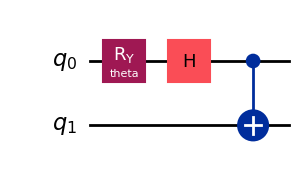

In [34]:
qc = QuantumCircuit(2)
qc.ry(Parameter("theta"),0)
qc.h(0)
qc.cx(0,1)
qc.draw("mpl")

In [35]:
observable = SparsePauliOp(["II", "XX", "YY", "ZZ"], coeffs=[1,1,-1,1])

params = [[0], [np.pi/6], [np.pi/2]]

In [8]:
pm = generate_preset_pass_manager(optimization_level=3)
transpiled_ckt = pm.run(qc)
observable = observable.apply_layout(transpiled_ckt.layout)

In [9]:
estimator = StatevectorEstimator()

In [10]:
job = estimator.run([(transpiled_ckt, observable, params)], precision=0.05)
result = job.result()

print("Result shape:", result[0].data.evs.shape)
print("Expectation values:\n", result[0].data.evs)

Result shape: (3,)
Expectation values:
 [3.90564358 3.69553826 2.00312561]


## Estimator Output

The output is a PubResult, with both data and metadata. The data contains at least an array of expectation values (PubResult.data.evs) and associated standard deviations (either PubResult.data.stds or PubResult.data.ensemble_standard_error depending on the resilience_level used), but can contain more data depending on the error mitigation options that were specified.

**Standard Deviation (stds)**
Measures how much individual shot results vary from each other.

**Standard Error (ensemble_standard_error)**
Measures how accurate your final expectation value is.

True value:      0.87

Your estimate:   0.85  ← how far off could this be?

Standard error = ±0.02  ← this far off

## How the Estimator calculates error

#### Case 1: No Twirling, No ZNE

Every shot gives one estimate of ⟨O⟩. All shots are treated as one big pool:

shots: +1, -1, +1, +1, -1, -1, +1 ...

average = 0.14

error = σ / √(total shots)

Both stds and ensemble_standard_error are equal here.

More shots → smaller error → more confident answer

#### Case 2: With Twirling Enabled

twirling = running slightly different versions of the circuit to randomize noise.

Now your shots are grouped by twirl version:

Twirl 1: +1, -1, +1  → average = 0.33

Twirl 2: -1, +1, +1  → average = 0.33

Twirl 3: +1, +1, -1  → average = 0.33
...

stds here is more meaningful because it captures how consistently different circuit versions agree with each other — not just random shot noise.

#### Case 3: With ZNE Enabled

noise level 1 → ⟨O⟩ = 0.70

noise level 2 → ⟨O⟩ = 0.55

noise level 3 → ⟨O⟩ = 0.40
         ↓
fit a curve and extrapolate back to noise=0
         ↓
true answer ≈ 0.87

Now stds = uncertainty of the curve fit at zero noise

good fit  → stds is small  → trust the answer

bad fit   → stds is HUGE   → don't trust the answer

evs_noise_factors → the raw ⟨O⟩ values at each noise level

stds_noise_factors → uncertainties at each noise level

## Estimator on QiskitRuntimeService

In [11]:
from qiskit_ibm_runtime import QiskitRuntimeService

service = QiskitRuntimeService()

In [12]:
backend = service.least_busy(operational=True, simulator=False, min_num_qubits=127)
backend.name

'ibm_kingston'

In [13]:
from qiskit.circuit.library import QAOAAnsatz

entanglement = [tuple(edge) for edge in backend.coupling_map.get_edges()]
entanglement[:10] # which qubits are connected on the chip

[(0, 1),
 (1, 0),
 (1, 2),
 (2, 1),
 (2, 3),
 (3, 2),
 (3, 4),
 (3, 16),
 (4, 3),
 (4, 5)]

In earlier generations of quantum hardware, some connections were "one-way" (e.g., we could only use Qubit 0 as a Control and Qubit 1 as a Target for a CNOT gate).

Most modern IBM chips (like the 127-qubit ibm_marrakesh you are using) support "bidirectional" CNOT gates.

In [14]:
observable = SparsePauliOp.from_sparse_list(
    [("ZZ", [i, j], 0.5) for i, j in entanglement],
    num_qubits=backend.num_qubits,
)

In [15]:
circuit = QAOAAnsatz(observable, reps=2)
# the circuit is parametrized, so we will define the parameter values for execution
param_values = [0.1, 0.2, 0.3, 0.4]

It creates two types of layers:

Cost Layer: Gates that implement the ZZ interactions from your observable.

Mixer Layer: Gates (usually RX) that allow the qubits to "tunnel" or explore different states.

In [16]:
pm = generate_preset_pass_manager(optimization_level=2, backend=backend)
isa_circuit = pm.run(circuit)
isa_observable = observable.apply_layout(isa_circuit.layout)
print(f">>> Circuit ops (ISA): {isa_circuit.count_ops()}")

>>> Circuit ops (ISA): OrderedDict({'rz': 2552, 'sx': 1692, 'cz': 928})


In [17]:
from qiskit_ibm_runtime import EstimatorV2 as Estimator

estimator = Estimator(mode=backend)

In [18]:
job = estimator.run([(isa_circuit, isa_observable, param_values)])
print(f">>> Job ID: {job.job_id()}")
print(f">>> Job Status: {job.status()}")

>>> Job ID: d7o402ik4prs73dsvu1g
>>> Job Status: QUEUED


In [19]:
result = job.result()
print(f">>> {result}")
print(f"  > Expectation value: {result[0].data.evs}")
print(f"  > Metadata: {result[0].metadata}")

>>> PrimitiveResult([PubResult(data=DataBin(evs=np.ndarray(<shape=(), dtype=float64>), stds=np.ndarray(<shape=(), dtype=float64>), ensemble_standard_error=np.ndarray(<shape=(), dtype=float64>)), metadata={'shots': 4096, 'target_precision': 0.015625, 'circuit_metadata': {}, 'resilience': {}, 'num_randomizations': 32})], metadata={'dynamical_decoupling': {'enable': False, 'sequence_type': 'XX', 'extra_slack_distribution': 'middle', 'scheduling_method': 'alap'}, 'twirling': {'enable_gates': False, 'enable_measure': True, 'num_randomizations': 'auto', 'shots_per_randomization': 'auto', 'interleave_randomizations': True, 'strategy': 'active-accum'}, 'resilience': {'measure_mitigation': True, 'zne_mitigation': False, 'pec_mitigation': False}, 'version': 2})
  > Expectation value: 27.112304860330454
  > Metadata: {'shots': 4096, 'target_precision': 0.015625, 'circuit_metadata': {}, 'resilience': {}, 'num_randomizations': 32}


## Run multiple experiments in a single job

In [36]:
from qiskit.circuit.library import iqp
from qiskit.quantum_info import random_hermitian

n_qubits = 50

service = QiskitRuntimeService()
backend = service.least_busy(
    operational=True, simulator=False, min_num_qubits=n_qubits
)

rng = np.random.default_rng()
mats = [np.real(random_hermitian(n_qubits, seed=rng)) for _ in range(3)]

pubs = []
circuits = [iqp(mat) for mat in mats]
observables = [
    SparsePauliOp("X" * 50),
    SparsePauliOp("Y" * 50),
    SparsePauliOp("Z" * 50),
]

# Get ISA circuits
pm = generate_preset_pass_manager(optimization_level=3, backend=backend)

for qc, obs in zip(circuits, observables):
    isa_circuit = pm.run(qc)
    isa_obs = obs.apply_layout(isa_circuit.layout)
    pubs.append((isa_circuit, isa_obs))

estimator = Estimator(backend)
job = estimator.run(pubs)
job_result = job.result()

for idx in range(len(pubs)):
    pub_result = job_result[idx]
    print(f">>> Expectation values for PUB {idx}: {pub_result.data.evs}")
    print(f">>> Standard errors for PUB {idx}: {pub_result.data.stds}")

>>> Expectation values for PUB 0: -0.008115647983768704
>>> Standard errors for PUB 0: 0.0780408265300047
>>> Expectation values for PUB 1: -0.0562474889513861
>>> Standard errors for PUB 1: 0.0504396705038596
>>> Expectation values for PUB 2: -0.07920792079207921
>>> Standard errors for PUB 2: 0.053179494032705096


## Quasi Probability

Error Mitigation techniques like **PEC** works by cancelling noise mathematically.
It runs many circuits and assigns positive and negative weights to results to subtract out the noise effect:

|00⟩ → +0.52

|11⟩ → +0.49

|01⟩ → -0.02  ← negative!

|10⟩ → +0.01

It adds upto 1 but has negative values. It's a mathematical artifact — it means that result was subtracted during noise cancellation, like noise-cancelling headphones adding an inverted sound wave to kill noise.

## Error mitigation and suppression techniques

Error mitigation and error suppression techniques are used to improve result quality when scaling up to larger workloads.

**Error Suppression**: These techniques happen during the circuit execution. They change how the hardware physically runs the gates to prevent errors from happening in the first place. Ex: Dynamical Decouling, Pauli Twirling

**Error Mitigation**: These techniques happen after the circuit is run. You collect noisy data and then use "post-processing" math to calculate what the noise-free answer should have been.

### Dynamical Decouling

In [21]:
estimator = Estimator(mode=backend)
estimator.options.dynamical_decoupling.enable = True
estimator.options.dynamical_decoupling.sequence_type = "XpXm"

### Pauli Twirling

Twirling, also known as randomized compiling, is a widely used technique for converting arbitrary noise channels into noise channels with more specific structure.

Pauli twirling is a special kind of twirling that uses Pauli operations. It has the effect of transforming any quantum channel into a Pauli channel. Performed alone, it can mitigate coherent noise because coherent noise tends to accumulate quadratically with the number of operations, whereas Pauli noise accumulates linearly. Pauli twirling is often combined with other error mitigation techniques that work better with Pauli noise than with arbitrary noise.

Pauli twirling is implemented by sandwiching a chosen set of gates with randomly chosen single-qubit Pauli gates in such a way that the ideal effect of the gate remains the same. The result is that a single circuit is replaced with a random ensemble of circuits, all with the same ideal effect. When sampling the circuit, samples are drawn from multiple random instances, rather than just a single one.

Since most of the errors in current quantum hardware come from two-qubit gates, this technique is often applied exclusively to (native) two-qubit gates. 

<img src="twirling.png" width="500">

<img src="pauli_twirls.png" width="500">

When twirling is enabled, the Estimator doesn't just run your circuit over and over. It creates a random ensemble of different circuits that are all mathematically identical but physically different.

#### 1. num_randomizations
This is the number of different versions of your circuit that will be created.

The Concept: Each randomization uses different randomly chosen Pauli gates to "wrap" your two-qubit gates.

Why it matters: The more randomizations you use, the better the twirling is at "averaging out" coherent hardware errors (like over-rotations) into simple, predictable noise.

#### 2. shots_per_randomization
This is how many times each specific version of the circuit is executed.

The Concept: For every one of the "randomized" circuits created above, the backend will run it this many times to get a stable probability distribution.

Why it matters: This controls the statistical precision for each individual circuit variation.

**$$\text{Total Shots} = \text{num_randomizations} \times \text{shots_per_randomization}$$**

In [22]:
estimator = Estimator(mode=backend)
estimator.options.twirling.enable_gates = True
estimator.options.twirling.num_randomizations = 32
estimator.options.twirling.shots_per_randomization = 100

**1. Mitigation Distorts the Native Distribution**

Techniques like Readout Error Mitigation (REM) or Probabilistic Error Cancellation (PEC) work by mathematically inverting noise — but this produces unphysical/negative quasi-probabilities. The Sampler is supposed to return a valid probability distribution (all values between 0 and 1, summing to 1). Mitigation breaks this guarantee.

**2. Mitigation is an Expectation-Value Concept**

Most error mitigation techniques (ZNE, PEC, CDRE) are designed around expectation values — which is exactly what the Estimator primitive computes. They work by:

Running circuits at different noise levels
Extrapolating to zero noise
Averaging over many runs

This only makes sense for scalar observables ⟨O⟩, not for full bit-string distributions.

**3. Sampling is Already the "Raw Truth"**

Measurement is the fundamental operation. The Sampler gives you the closest thing to what the quantum hardware actually produced. Error mitigation would introduce:

Post-processing bias — the distribution no longer reflects what the circuit actually did
Statistical artifacts — especially problematic for applications like quantum simulation or VQE that need authentic shot statistics

### Twirled Readout Erro Extinction (TREX)

This focuses on measurement errors. It uses a calibration matrix to "undo" the effect of a qubit being read as a $|1\rangle$ when it was actually a $|0\rangle$. TREX works by randomly "twirling" each measurement. Instead of measuring directly, each measurement is randomly replaced by a 3-step sequence:

|ψ⟩ ──[X]──[M]──[⊕1]──

In a noiseless world, this sequence is identical to a plain measurement — the X gate and classical bit flip cancel out exactly. But in a noisy world, something useful happens.

Readout noise is described by a transfer matrix Λ, where each entry Λ[i][j] is the probability of measuring outcome i when the true state is j. In general, this matrix is complex and hard to invert.

Measurement twirling has a powerful mathematical effect: it diagonalizes Λ. A diagonal transfer matrix is trivially invertible — you just divide by the diagonal entries. This turns a hard calibration problem into a simple one.

In [23]:
estimator = Estimator(mode=backend)
estimator.options.resilience.measure_mitigation = True
estimator.options.resilience.measure_noise_learning.num_randomizations = 32
estimator.options.resilience.measure_noise_learning.shots_per_randomization = 100

### Zero Noise Extrapolation (ZNE)

ZNE is an error mitigation technique used to get better estimates of expectation values ⟨O⟩ from noisy quantum hardware. It works on a clever idea: if you can't remove noise, understand it — then mathematically extrapolate to where it would be zero.

1. Intentionally increases noise in a controlled way

2. Observes how the expectation value degrades

3. Fits a curve through those noisy results and extrapolates back to zero noise

**Stage 1 — Noise Amplification (Digital Gate Folding)**

Qiskit Runtime amplifies noise by replacing 2-qubit gates with longer equivalent sequences:

Original:        U

Noise factor 3:  U U† U       (same operation, 3× the noise)

Noise factor 5:  U U† U U† U  (same operation, 5× the noise)

Since U†U = I (identity), these sequences are mathematically identical but physically noisier because more gate executions = more decoherence and gate errors.

The noise factor directly controls how much amplification you apply.

**Stage 2 — Extrapolation**

After collecting expectation values at multiple noise levels, you fit a curve and extrapolate to noise = 0:

Noise factor:    1     3     5
⟨O⟩ measured:   0.61  0.48  0.35
                  \     |    /
                   curve fit
                        ↓
              Extrapolated at 0 → ~0.74  ✓

You can choose the functional form of the fit:

Linear — simple, works when noise effect is mild

Exponential — better for stronger noise regimes

Polynomial — more flexible, needs more data points

In [24]:
estimator = Estimator(mode=backend)
estimator.options.resilience.zne_mitigation = True
estimator.options.resilience.zne.noise_factors = (1, 3, 5)
estimator.options.resilience.zne.extrapolator = "exponential"

### Probabilisitic Error Amplification (PEA)

One of the main challenges in ZNE is to accurately amplify the noise affecting the target circuit. Gate folding provides an easy way to perform this amplification, but is potentially inaccurate and might lead to incorrect results.

Probabilistic error amplification provides a more accurate approach to error amplification through noise learning.

**PEA consists of three stages:**

1. Learning: The twirled noise model of each layer of entangling gates in the circuit is learned.

Runs preliminary experiments specifically targeting each layer of entangling (2-qubit) gates

Reconstructs the twirled noise model — a characterization of what kind of noise each layer actually produces

Twirling means randomly applying Pauli gates to symmetrize the noise, making it easier to characterize

2. Noise amplification: The original quantum circuit is executed multiple times at different noise factors.

3. Extrapolation: The ideal result is estimated by extrapolating the noisy expectation value results to the zero-noise limit.

In [25]:
estimator = Estimator(mode=backend)
estimator.options.resilience.zne_mitigation = True
estimator.options.resilience.zne.amplifier = "pea"

### Probabilistic Error Cancellation (PEC)

PEC mathematically cancels noise by expressing the ideal circuit as a combination of noisy ones.

If all ηᵢ were positive and summed to 1, they'd form a normal probability distribution and you could just sample from them directly. But in reality:

Some ηᵢ are negative — making it a quasi-probability distribution

This means some circuits contribute with a negative sign to the final sum, which creates sampling overhead.

In [26]:
estimator = Estimator(mode=backend)
estimator.options.resilience.pec_mitigation = True
estimator.options.resilience.pec.max_overhead = 100

## Estimator Options

If you do not specify a value for an option, it is given a special value of Unset and the server defaults are used.

In [27]:
from qiskit_ibm_runtime.options import EstimatorOptions

options = EstimatorOptions(
    resilience_level=2,
    resilience={"zne_mitigation": True, "zne": {"noise_factors": [1, 3, 5]}}, # which noise levels to sample
)

# or...
options = EstimatorOptions()
options.resilience_level = 2
options.resilience.zne_mitigation = True
options.resilience.zne.noise_factors = [1, 3, 5]

estimator = Estimator(mode=backend, options=options)

# or
# Setting options during primitive initialization
estimator = Estimator(
    backend,
    options={
        "resilience_level": 2,
        "resilience": {
            "zne_mitigation": True,
            "zne": {"noise_factors": [1, 3, 5]},
        }
    }
)

# or
estimator = Estimator(mode=backend)

# Setting options after primitive initialization
# This uses auto-complete.
estimator.options.default_shots = 4000
# This does bulk update.
estimator.options.update(
    default_shots=4000, resilience={"zne_mitigation": True}
)

### Resilience level (Estimator only)

level 0 turns off all error mitigation

level 1 turns on options for measurement error mitigation

level 2 turns on options for gate and measurement error mitigation.

setting the resilience level to 0 initially turns off zne_mitigation, but **estimator.options.resilience.zne_mitigation = True** overrides the relevant setup from **estimator.options.resilience_level = 0**.

In [28]:
estimator = Estimator(backend)

estimator.options.default_shots = 100
estimator.options.resilience_level = 0
estimator.options.resilience.zne_mitigation = True

### ResilienceOptionsV2 Definitions

| Option | Type | Description |
| :--- | :--- | :--- |
| **`measure_mitigation`** | `bool` | Enables **Readout Error Mitigation**. Default: `False` (Level 0), `True` (Levels 1 & 2). |
| **`measure_noise_learning`** | `Dict` | Options for fine-tuning noise learning for measurement mitigation. |
| **`zne_mitigation`** | `bool` | Enables **Zero-Noise Extrapolation (ZNE)**. Default: `True` only for Level 2. |
| **`zne`** | `Dict` | Configuration for ZNE (extrapolator types, noise factors). |
| **`pec_mitigation`** | `bool` | Enables **Probabilistic Error Cancellation (PEC)**. Default: `False`. |
| **`pec`** | `Dict` | Configuration for PEC (e.g., max sampling overhead). |
| **`layer_noise_learning`** | `Dict` | Options for learning the noise model of circuit layers. |
| **`layer_noise_model`** | `Object` | A pre-computed noise model; if provided, it skips the learning stage. |

### ZNE Options

### ZneOptions Definitions (V2 Estimator)

| Option | Type | Description |
| :--- | :--- | :--- |
| **`amplifier`** | `str` | Technique for amplifying noise. Options: `'gate_folding'` (default), `'gate_folding_front'`, `'gate_folding_back'`, or `'pea'`. |
| **`noise_factors`** | `Sequence[float]` | The factors by which noise is amplified. Default is `(1, 3, 5)`. |
| **`extrapolator`** | `str` \| `List[str]` | The fit model used to reach zero noise. Options: `'exponential'`, `'linear'`, `'double_exponential'`, or `'polynomial_degree_(1-7)'`. Default: `("exponential", "linear")`. |
| **`extrapolated_noise_factors`** | `Sequence[float]` | Specific noise factors where the fit is evaluated for reporting. Defaults to `[0, *noise_factors]`. |

### Twirling Options

### TwirlingOptions Definitions (V2)

| Option | Type | Description |
| :--- | :--- | :--- |
| **`enable_gates`** | `bool` | Whether to apply 2-qubit Clifford gate twirling. For Estimator, defaults to `True` at resilience level 2. |
| **`enable_measure`** | `bool` | Whether to enable twirling for measurement instructions. Defaults to `True` for resilience levels 1 and 2. |
| **`num_randomizations`** | `int` \| `'auto'` | Number of random samples to use. Default is `'auto'`. |
| **`shots_per_randomization`** | `int` \| `'auto'` | Number of shots to run for each random sample. Default is `'auto'`. |
| **`strategy`** | `str` | Qubit twirling strategy. Options: `'active'`, `'active-accum'`, `'active-circuit'`, or `'all'`. Default: `'active-accum'`. |

### Estimator Options

### EstimatorOptions (V2) Core Definitions

| Option | Type | Description |
| :--- | :--- | :--- |
| **`resilience_level`** | `int` | The overall error mitigation level. `0`: None, `1`: Readout (Default), `2`: ZNE/Bias reduction. |
| **`default_precision`** | `float` | Target error bar for expectation values. Default is `0.015625` (equivalent to 4096 shots). |
| **`default_shots`** | `int` | Total shots per circuit. If set, this **overrides** `default_precision`. |
| **`optimization_level`** | `int` | How much the compiler should optimize your circuit. Usually ranges from `0` to `3`. |
| **`seed_estimator`** | `int` | Seed used to control randomness in sampling. |
| **`resilience`** | `dict` | Advanced sub-options for ZNE, PEC, and Readout mitigation. |
| **`twirling`** | `dict` | Sub-options for Pauli twirling (gate and measurement). |
| **`dynamical_decoupling`** | `dict` | Options for inserting pulses during qubit idle time to reduce decoherence. |